# 01 Cross Asset Overview

**Book:** *Global Macro Trading \u2014 Profiting in a New World Economy*  
**Focus:** Build a local cross-asset return and rate-change panel, then compute broad and recent correlation matrices from the available parquet lake.


## Goals

1. Load liquid price proxies from the local `data/market_data/prices` parquet files.
2. Load daily Treasury, credit, and inflation-expectation proxies from the local FRED parquet files.
3. Convert prices into log returns and FRED rates/spreads into daily changes.
4. Compute full-sample and recent 60-business-day cross-asset correlation matrices.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-27_global_macro_trading_gliner"
FRED_DIR = REPO_ROOT / "data" / "market_data" / "fred"
PRICES_DIR = REPO_ROOT / "data" / "market_data" / "prices"
START = "2024-02-26"
END = "2026-02-27"
CORR_CSV = STUDY_DIR / "01_cross_asset_correlation_60d.csv"
PANEL_CSV = STUDY_DIR / "01_cross_asset_panel.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Study dir:", STUDY_DIR)
print("FRED dir exists:", FRED_DIR.exists())
print("Prices dir exists:", PRICES_DIR.exists())


Study dir: /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-27_global_macro_trading_gliner
FRED dir exists: True
Prices dir exists: True


In [2]:
def _filter_date(frame: pd.DataFrame, start=START, end=END, date_col="date"):
    out = frame.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out[(out[date_col] >= start) & (out[date_col] <= end)]


def load_fred_series(series_ids, start=START, end=END):
    frames = []
    for parquet_file in sorted(FRED_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "series_id" not in df.columns:
            continue
        sub = df[df["series_id"].isin(series_ids)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "series_id"])
    wide = (
        joined.pivot(index="date", columns="series_id", values="value")
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


def load_local_price_series(tickers, start=START, end=END, value_col="close"):
    frames = []
    for parquet_file in sorted(PRICES_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "ticker" not in df.columns or value_col not in df.columns:
            continue
        sub = df[df["ticker"].isin(tickers)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "ticker"])
    wide = (
        joined.pivot(index="date", columns="ticker", values=value_col)
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


In [3]:
price_panel = load_local_price_series(["SPY", "DX-Y.NYB", "GC=F", "CL=F", "^VIX"])
price_panel = price_panel.reindex(pd.date_range(START, END, freq="B")).ffill()
price_panel.index.name = "date"

fred_panel = load_fred_series(["DGS10", "T10Y2Y", "T10YIE", "BAMLH0A0HYM2", "SOFR"])
fred_panel = fred_panel.reindex(pd.date_range(START, END, freq="B")).ffill()
fred_panel.index.name = "date"

price_returns = np.log(price_panel).diff().rename(columns={
    "SPY": "spy_ret",
    "DX-Y.NYB": "dxy_ret",
    "GC=F": "gold_ret",
    "CL=F": "wti_ret",
    "^VIX": "vix_ret",
})

fred_changes = fred_panel.diff().rename(columns={
    "DGS10": "dgs10_chg",
    "T10Y2Y": "curve_2s10s_chg",
    "T10YIE": "breakeven_10y_chg",
    "BAMLH0A0HYM2": "hy_oas_chg",
    "SOFR": "sofr_chg",
})

cross_asset_panel = pd.concat([price_returns, fred_changes], axis=1).dropna()
cross_asset_panel.tail()


             wti_ret   dxy_ret  gold_ret   spy_ret   vix_ret  hy_oas_chg  dgs10_chg  sofr_chg  curve_2s10s_chg  breakeven_10y_chg
date                                                                                                                             
2026-02-23 -0.001206 -0.001023  0.028334 -0.010264  0.095834        0.09      -0.05      0.00             0.00              -0.02
2026-02-24 -0.010308  0.001841 -0.009440  0.007242 -0.072023        0.02       0.00      0.01             0.01               0.00
2026-02-25 -0.003205 -0.001841  0.009766  0.008403  0.000000       -0.03       0.02      0.00            -0.01               0.02
2026-02-26 -0.003215  0.000921 -0.005759 -0.005570 -0.048202        0.04       0.00      0.00             0.00               0.00
2026-02-27  0.031399 -0.001474  0.022898 -0.004814  0.063935        0.00       0.00      0.00            -0.01              -0.03

In [4]:
full_sample_corr = cross_asset_panel.corr().round(3)
recent_corr = cross_asset_panel.tail(60).corr().round(3)

pair_summary = (
    recent_corr.where(np.triu(np.ones(recent_corr.shape), k=1).astype(bool))
    .stack()
    .rename("corr_60d")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame()
)

print("Full-sample observations:", len(cross_asset_panel))
print("Top 10 absolute 60-day correlations:")
print(pair_summary.head(10).to_string())
recent_corr


Full-sample observations: 524
Top 10 absolute 60-day correlations:
                              corr_60d
spy_ret    vix_ret              -0.831
           hy_oas_chg           -0.710
vix_ret    hy_oas_chg            0.649
dgs10_chg  breakeven_10y_chg     0.608
hy_oas_chg breakeven_10y_chg    -0.503
dxy_ret    gold_ret             -0.467
hy_oas_chg dgs10_chg            -0.450
dgs10_chg  curve_2s10s_chg       0.385
wti_ret    breakeven_10y_chg     0.318
spy_ret    breakeven_10y_chg     0.306


                   wti_ret  dxy_ret  gold_ret  spy_ret  vix_ret  hy_oas_chg  dgs10_chg  sofr_chg  curve_2s10s_chg  breakeven_10y_chg
wti_ret              1.000   -0.213     0.254    0.036    0.032      -0.148      0.160    -0.052            0.152              0.318
dxy_ret             -0.213    1.000    -0.467   -0.055   -0.026      -0.057      0.085     0.107           -0.272              0.036
gold_ret             0.254   -0.467     1.000    0.096   -0.036      -0.139      0.054    -0.195           -0.023              0.122
spy_ret              0.036   -0.055     0.096    1.000   -0.831      -0.710      0.078    -0.130           -0.212              0.306
vix_ret              0.032   -0.026    -0.036   -0.831    1.000       0.649     -0.110     0.149            0.165             -0.208
hy_oas_chg          -0.148   -0.057    -0.139   -0.710    0.649       1.000     -0.450     0.038            0.172             -0.503
dgs10_chg            0.160    0.085     0.054    0.078   -0.110      

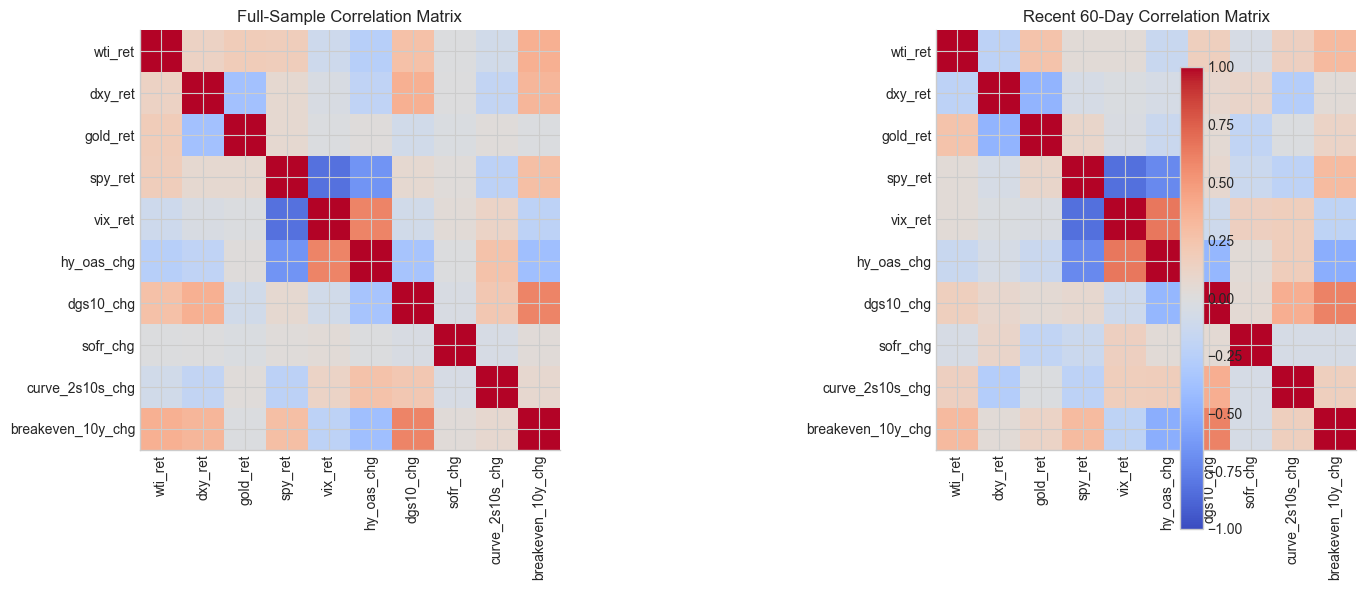

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, matrix, title in [
    (axes[0], full_sample_corr, "Full-Sample Correlation Matrix"),
    (axes[1], recent_corr, "Recent 60-Day Correlation Matrix"),
]:
    image = ax.imshow(matrix.values, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=90)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_title(title)

fig.colorbar(image, ax=axes, fraction=0.025, pad=0.04)
plt.tight_layout()
plt.show()


In [6]:
cross_asset_panel.to_csv(PANEL_CSV)
recent_corr.to_csv(CORR_CSV)
print("saved panel to", PANEL_CSV)
print("saved 60-day correlation matrix to", CORR_CSV)
cross_asset_panel.tail()


saved panel to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-27_global_macro_trading_gliner/01_cross_asset_panel.csv
saved 60-day correlation matrix to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-27_global_macro_trading_gliner/01_cross_asset_correlation_60d.csv


             wti_ret   dxy_ret  gold_ret   spy_ret   vix_ret  hy_oas_chg  dgs10_chg  sofr_chg  curve_2s10s_chg  breakeven_10y_chg
date                                                                                                                             
2026-02-23 -0.001206 -0.001023  0.028334 -0.010264  0.095834        0.09      -0.05      0.00             0.00              -0.02
2026-02-24 -0.010308  0.001841 -0.009440  0.007242 -0.072023        0.02       0.00      0.01             0.01               0.00
2026-02-25 -0.003205 -0.001841  0.009766  0.008403  0.000000       -0.03       0.02      0.00            -0.01               0.02
2026-02-26 -0.003215  0.000921 -0.005759 -0.005570 -0.048202        0.04       0.00      0.00             0.00               0.00
2026-02-27  0.031399 -0.001474  0.022898 -0.004814  0.063935        0.00       0.00      0.00            -0.01              -0.03